# Time domain baseline correction (NMR)

Here we show how to baseline correct dataset in the time domain before applying FFT.

The example spectra were downloaded from a historical University of Tubingen
NMR processing page describing DC-offset correction. That original external
page is no longer reliably reachable, so the example below focuses on the
SpectroChemPy workflow directly.

In [1]:
import warnings

import spectrochempy as scp

In [2]:
# This example uses Bruker NMR data.
#
# Requires the official ``spectrochempy-nmr`` plugin.
# Install with: ``python -m pip install "spectrochempy[nmr]"``.

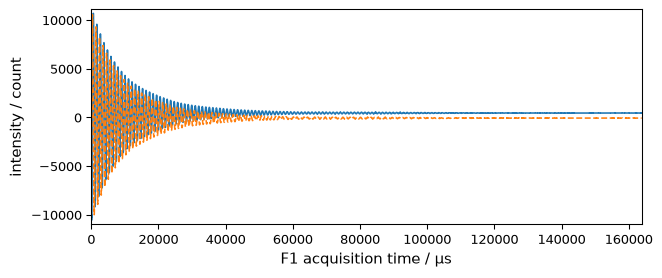

In [3]:
path = scp.preferences.datadir / "nmrdata" / "bruker" / "tests" / "nmr" / "h3po4"
fid = scp.nmr.read(path, expno=4)
prefs = scp.preferences
prefs.figure.figsize = (7, 3)
_ = fid.plot(show_complex=True)

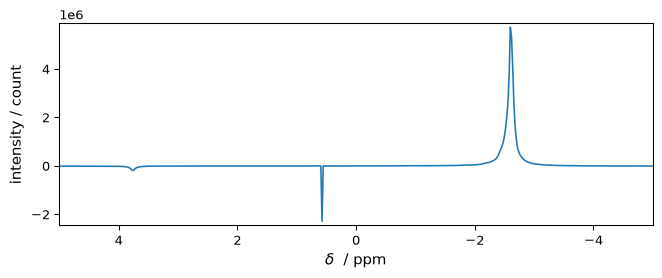

In [4]:
spec = scp.fft(fid)
_ = spec.plot(xlim=(5, -5))

We can see that in the middle of the spectrum there are an artifact (a transmitter spike)
due to different DC offset between imaginary.

In SpectroChemPy, for now, we provide a simple kind of dc correction using the `dc`command.

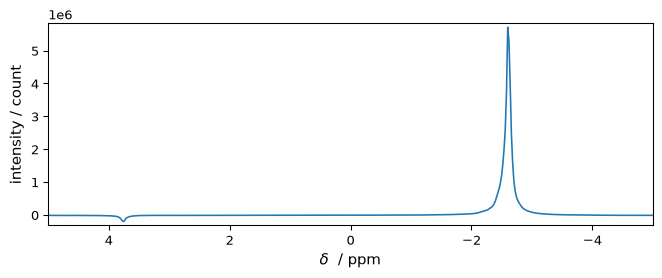

In [5]:
dc_corrected_fid = fid.dc()
spec = scp.fft(dc_corrected_fid)
_ = spec.plot(xlim=(5, -5))

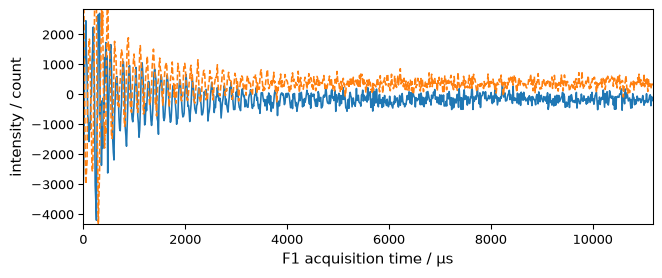

In [6]:
path = scp.preferences.datadir / "nmrdata" / "bruker" / "tests" / "nmr" / "cadmium"
# This compact documentation fixture intentionally contains fewer points than
# advertised by its original Bruker metadata. The reader safely keeps all
# available points, so the resulting shape warning is not useful to the example.
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"\(956,\)cannot be shaped into\(1024,\)",
        category=UserWarning,
    )
    fid2 = scp.nmr.read(path, expno=100)
_ = fid2.plot(show_complex=True)

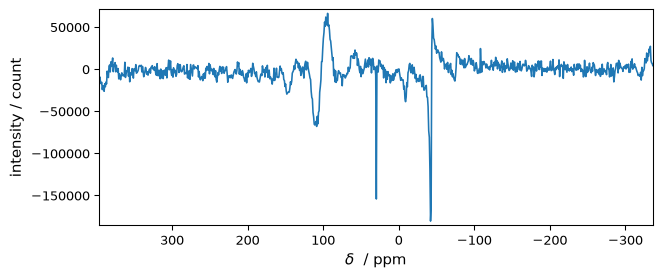

In [7]:
spec2 = scp.fft(fid2)
_ = spec2.plot()

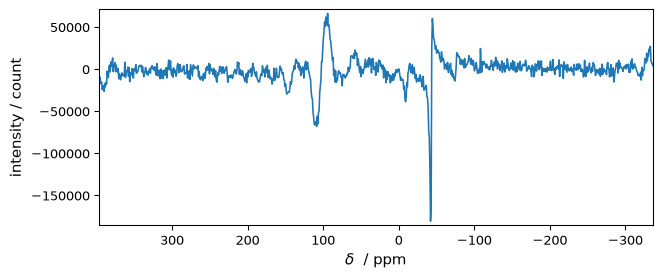

In [8]:
dc_corrected_fid2 = fid2.dc()
spec2 = scp.fft(dc_corrected_fid2)
_ = spec2.plot()